# Task 03: Cleaning Data

## Objective
The objective of this task is to clean a dataset by identifying missing values, duplicate records, inconsistent formatting, incorrect data types, and potential outliers. The cleaning decisions are documented to produce a reliable, analysis-ready dataset.

## Dataset
The Titanic passenger dataset (`tested.csv`) is used for this task. Python, pandas, NumPy, Matplotlib, and Seaborn are used to inspect, clean, and validate the data.

In [64]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Uploding the Dataset
from google.colab import files
uploaded = files.upload()

Saving tested.csv to tested (3).csv


In [66]:
# Reading th Dataset
df = pd.read_csv("tested.csv")
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Dataset loaded successfully!
Number of rows: 418
Number of columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [67]:
# Understand the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset information:")
df.info()
print("\nStatistical summary:")
display(df.describe(include="all").T)

Dataset shape: (418, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Survived,418.0,NaN,NaN,NaN,0.363636,0.481622,0.0,0.0,0.0,1.0,1.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Peter, Master. Michael J",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


In [68]:
# Create the initial data-quality report
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique(),
})
print("Initial Data Quality Report:")
display(quality_report)
print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

Initial Data Quality Report:


,Data Type,Missing Values,Missing Percentage,Unique Values
PassengerId,int64,0,0.00,418
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,object,0,0.00,418
Sex,object,0,0.00,2
Age,float64,86,20.57,79
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,8
Ticket,object,0,0.00,363
Fare,float64,1,0.24,169


Total rows: 418
Exact duplicate rows: 0


In [69]:
# Check numerical ranges and categorical values

range_checks = {
    "Negative Age values": (df["Age"] < 0).sum(),
    "Negative Fare values": (df["Fare"] < 0).sum(),
    "Invalid Passenger Classes": (~df["Pclass"].isin([1, 2, 3])).sum(),
    "Invalid Sex values": (
        ~df["Sex"].astype(str).str.strip().str.lower()
        .isin(["male", "female", "m", "f"])
    ).sum(),
    "Invalid Embarked values": (
        ~df["Embarked"].astype(str).str.strip().str.upper()
        .isin(["C", "Q", "S"])
    ).sum()
}

range_report = pd.DataFrame(
    list(range_checks.items()),
    columns=["Quality Check", "Number of Issues"]
)

display(range_report)

,Quality Check,Number of Issues
0,Negative Age values,0
1,Negative Fare values,0
2,Invalid Passenger Classes,0
3,Invalid Sex values,0
4,Invalid Embarked values,0


## Missing-Value Handling

- **Age:** Missing values are replaced with the median because the median is less sensitive to extreme values than the mean.
- **Fare:** Missing values are replaced with the median for the same reason.
- **Cabin:** Missing values are replaced with `"Unknown"` because the original cabin details are unavailable. A new `HasCabin` column records whether cabin information was originally present.
- **Other columns:** No imputation is needed if they contain no missing values.

These decisions preserve the passenger records while making the dataset easier to analyse.

In [70]:
# Check missing values and duplicate rows before cleaning
print("Missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nPercentage of missing values:")
print((df.isnull().mean() * 100).round(2))

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Total missing values: 414

Duplicate rows: 0

Percentage of missing values:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            20.57
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.24
Cabin          78.23
Embarked        0.00
dtype: float64


In [71]:
# Save the before-cleaning statistics
before_rows = len(df)
before_duplicates = df.duplicated().sum()
before_missing = df.isnull().sum().sum()
before_dtypes = df.dtypes.astype(str).to_dict()
before_summary = pd.DataFrame({
    "Metric": ["Number of rows","Total missing values","Duplicate rows"],
    "Before Cleaning": [before_rows,before_missing,before_duplicates]
})
display(before_summary)

,Metric,Before Cleaning
0,Number of rows,418
1,Total missing values,414
2,Duplicate rows,0


## Duplicate Removal

Exact duplicate rows are identified using pandas `duplicated()` and removed using `drop_duplicates()`. The original dataset contains no exact duplicate rows, so no records are removed in this step. Duplicate removal helps prevent repeated records from affecting analysis.

In [72]:
# Remove duplicate rows
duplicates_found = df.duplicated().sum()
df = df.drop_duplicates().copy()
print("Duplicate rows found:", duplicates_found)
print("Duplicate rows removed:", duplicates_found)
print("Rows remaining:", len(df))

Duplicate rows found: 0
Duplicate rows removed: 0
Rows remaining: 418


In [73]:
# Handle missing values
# Fill missing Age values using the median
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

# Fill missing Fare values using the median
fare_median = df["Fare"].median()
df["Fare"] = df["Fare"].fillna(fare_median)

# Record whether a cabin was originally provided
df["HasCabin"] = df["Cabin"].notna().astype(int)

# Preserve missing cabin information explicitly
df["Cabin"] = df["Cabin"].fillna("Unknown")
print("Missing values after handling:")
display(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Total missing values: 0


## Standardization

Text columns are cleaned by removing leading and trailing spaces. The `Sex` column is standardized to consistent capitalization, and the `Embarked` column is converted to uppercase.

The unique values are inspected after standardization. Only formatting differences that actually exist in the data should be reported as corrected.

In [74]:
# Standardize inconsistent formatting
# Remove leading and trailing spaces from text columns
text_columns = df.select_dtypes(include=["object"]).columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Standardize Sex
df["Sex"] = (df["Sex"].str.lower().replace({"m": "male","f": "female"}).str.capitalize())

# Standardize Embarked values
df["Embarked"] = df["Embarked"].str.upper()
print("Unique Sex values:")
print(df["Sex"].unique())
print("\nUnique Embarked values:")
print(df["Embarked"].unique())
print("\nStandardization completed.")

Unique Sex values:
['Male' 'Female']

Unique Embarked values:
['Q' 'S' 'C']

Standardization completed.


## Data-Type Correction

The `PassengerId` column is converted to a string because it represents an identifier rather than a measurement. Numerical columns such as `Age` and `Fare` are kept as numeric types, while categorical columns are kept as strings. Integer-valued columns are converted to nullable integer types where appropriate.

In [75]:
# Correct data types
# PassengerId is an identifier, so store it as a string
df["PassengerId"] = df["PassengerId"].astype(str)

# Correct integer columns
integer_columns = ["Survived", "Pclass", "SibSp", "Parch", "HasCabin"]
for col in integer_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Correct numeric columns
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce")

# Ensure categorical/text columns are strings
for col in ["Name", "Sex", "Ticket", "Cabin", "Embarked"]:
    df[col] = df[col].astype(str)
print("Data types after correction:")
df.info()

Data types after correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    object 
 1   Survived     418 non-null    Int64  
 2   Pclass       418 non-null    Int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    Int64  
 7   Parch        418 non-null    Int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        418 non-null    object 
 11  Embarked     418 non-null    object 
 12  HasCabin     418 non-null    Int64  
dtypes: Int64(5), float64(2), object(6)
memory usage: 44.6+ KB


In [76]:
after_rows = len(df)
after_columns = len(df.columns)
after_missing = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Duplicate rows"
    ],
    "Before Cleaning": [
        before_rows,
        len(before_dtypes),
        before_missing,
        before_duplicates
    ],
    "After Cleaning": [
        after_rows,
        after_columns,
        after_missing,
        after_duplicates
    ]
})

display(summary)

print("\nData type comparison:")
display(pd.DataFrame({
    "Before Cleaning": pd.Series(before_dtypes),
    "After Cleaning": df.dtypes.astype(str)
}))

,Metric,Before Cleaning,After Cleaning
0,Number of rows,418,418
1,Number of columns,12,13
2,Total missing values,414,0
3,Duplicate rows,0,0



Data type comparison:


,Before Cleaning,After Cleaning
Age,float64,float64
Cabin,object,object
Embarked,object,object
Fare,float64,float64
HasCabin,NaN,Int64
Name,object,object
Parch,int64,Int64
PassengerId,int64,object
Pclass,int64,Int64
Sex,object,object


## Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in `Age`, `Fare`, `SibSp`, and `Parch`.

The lower boundary is calculated as Q1 − 1.5 × IQR, and the upper boundary is calculated as Q3 + 1.5 × IQR.

Potential outliers are retained because unusually high fares or family counts may be genuine passenger records. They should only be removed or capped when there is evidence that they are invalid.

In [77]:
# Detect outliers using the IQR method
numeric_columns = ["Age", "Fare", "SibSp", "Parch"]
outlier_results = []
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_results.append({
        "Column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers)
    })
outlier_report = pd.DataFrame(outlier_results)
display(outlier_report)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,23.0,35.75,12.75,3.88,54.88,36
1,Fare,7.9,31.47,23.58,-27.47,66.84,55
2,SibSp,0.0,1.00,1.00,-1.50,2.50,11
3,Parch,0.0,0.00,0.00,0.00,0.00,94


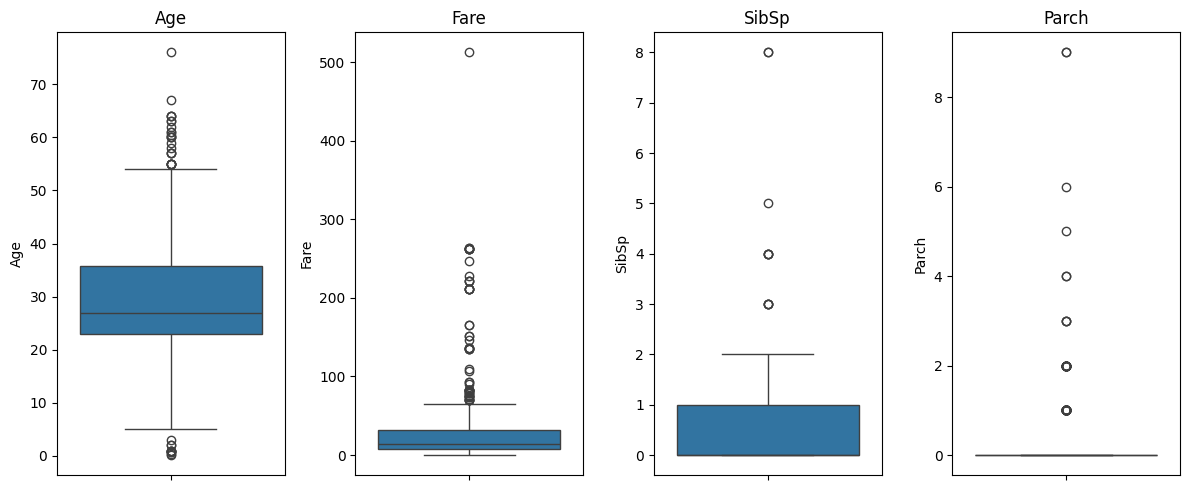

In [78]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [79]:
# Verify the cleaned dataset
print("Cleaned dataset shape:", df.shape)
print("\nMissing values:")
display(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nFinal data types:")
display(df.dtypes.astype(str).to_frame("Data Type"))
print("\nFirst 10 cleaned rows:")
display(df.head(10))

Cleaned dataset shape: (418, 13)

Missing values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Duplicate rows: 0

Final data types:


,Data Type
PassengerId,object
Survived,Int64
Pclass,Int64
Name,object
Sex,object
Age,float64
SibSp,Int64
Parch,Int64
Ticket,object
Fare,float64



First 10 cleaned rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
0,892,0,3,"Kelly, Mr. James",Male,34.5,0,0,330911,7.8292,Unknown,Q,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",Female,47.0,1,0,363272,7.0000,Unknown,S,0
2,894,0,2,"Myles, Mr. Thomas Francis",Male,62.0,0,0,240276,9.6875,Unknown,Q,0
3,895,0,3,"Wirz, Mr. Albert",Male,27.0,0,0,315154,8.6625,Unknown,S,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Female,22.0,1,1,3101298,12.2875,Unknown,S,0
5,897,0,3,"Svensson, Mr. Johan Cervin",Male,14.0,0,0,7538,9.2250,Unknown,S,0
6,898,1,3,"Connolly, Miss. Kate",Female,30.0,0,0,330972,7.6292,Unknown,Q,0
7,899,0,2,"Caldwell, Mr. Albert Francis",Male,26.0,1,1,248738,29.0000,Unknown,S,0
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",Female,18.0,0,0,2657,7.2292,Unknown,C,0
9,901,0,3,"Davies, Mr. John Samuel",Male,21.0,2,0,A/4 48871,24.1500,Unknown,S,0


In [80]:
# Create the before-versus-after summary table
after_rows = len(df)
after_duplicates = df.duplicated().sum()
after_missing = df.isnull().sum().sum()
summary = pd.DataFrame({
    "Metric": ["Number of rows","Total missing values","Duplicate rows"],
    "Before Cleaning": [before_rows,before_missing,before_duplicates],
    "After Cleaning": [after_rows,after_missing,after_duplicates]
})
display(summary)

,Metric,Before Cleaning,After Cleaning
0,Number of rows,418,418
1,Total missing values,414,0
2,Duplicate rows,0,0


In [81]:
dtype_comparison = pd.DataFrame({
    "Before Cleaning": pd.Series(before_dtypes),
    "After Cleaning": df.dtypes.astype(str)
})
display(dtype_comparison)

,Before Cleaning,After Cleaning
Age,float64,float64
Cabin,object,object
Embarked,object,object
Fare,float64,float64
HasCabin,NaN,Int64
Name,object,object
Parch,int64,Int64
PassengerId,int64,object
Pclass,int64,Int64
Sex,object,object


In [82]:
print("FINAL VALIDATION")
print("-" * 30)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("PassengerId is string:",
      pd.api.types.is_string_dtype(df["PassengerId"]))
print("Age is numeric:",
      pd.api.types.is_numeric_dtype(df["Age"]))
print("Fare is numeric:",
      pd.api.types.is_numeric_dtype(df["Fare"]))

FINAL VALIDATION
------------------------------
Rows: 418
Columns: 13
Missing values: 0
Duplicate rows: 0
PassengerId is string: True
Age is numeric: True
Fare is numeric: True


## Conclusion

The Titanic dataset was inspected and cleaned using pandas and NumPy. Missing values in `Age`, `Fare`, and `Cabin` were handled using documented strategies. Duplicate rows were checked and removed where applicable, text formatting was standardized, and data types were corrected.

Potential outliers were identified using the IQR method and retained where they could represent valid observations. The before-and-after summary and validation checks were used to review the cleaning process.

The final dataset was exported as `Titanic_Cleaned.csv` for further analysis.

**Limitation:** The dataset resembles a Titanic test dataset. The reliability and origin of the `Survived` column should be verified before using it for predictive modelling.

In [83]:
# Save the cleaned dataset as a new CSV
output_file = "Titanic_Cleaned.csv"
df.to_csv(output_file, index=False)
print("Cleaned dataset saved as:", output_file)

Cleaned dataset saved as: Titanic_Cleaned.csv


In [84]:
# Download the cleaned CSV
files.download("Titanic_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>